# Arabic Handwritten Character Recognition, Retrieval, and Metric Learning

This single notebook takes the project from baseline training to transfer learning, image retrieval, and Phase 3 metric learning.

Pipeline:
1. Prepare dataset and augmentations
2. Train a CNN from scratch
3. Fine-tune a pretrained model
4. Compare results
5. Build image retrieval with embeddings
6. Train an embedding model with Triplet Loss


## 1) Setup

Run this first. If you are using Colab, enable GPU from `Runtime > Change runtime type > GPU`.

In [2]:
import os
import math
import time
import copy
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import kagglehub
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch version:', torch.__version__)
print('Torchvision version:', torchvision.__version__)
print('Device:', device)

Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Device: cuda


## 2) Configuration

Update `DATA_ROOT` to point to your Arabic handwritten characters dataset.

Supported layouts:
- `DATA_ROOT/train/<class_name>/*.png` and optionally `val/`, `test/`
- or `DATA_ROOT/<class_name>/*.png` and the notebook will create train/val/test splits automatically


In [5]:
import kagglehub

dataset_path = kagglehub.dataset_download("mloey1/ahcd1")
DATA_ROOT = Path(dataset_path)

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
NUM_EPOCHS_SCRATCH = 20
NUM_EPOCHS_TRANSFER = 20
NUM_EPOCHS_METRIC = 20
LEARNING_RATE_SCRATCH = 1e-3
LEARNING_RATE_TRANSFER = 3e-4
LEARNING_RATE_METRIC = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.01
DROPOUT = 0.30
FREEZE_BACKBONE_EPOCHS = 1
PATIENCE = 6
EMBED_DIM = 128
MARGIN = 0.35
USE_MIXED_PRECISION = torch.cuda.is_available()

SCRATCH_OPTIMIZER = 'adamw'
TRANSFER_OPTIMIZER = 'adamw'
METRIC_OPTIMIZER = 'adamw'

TRANSFER_MODEL_NAME = 'efficientnet_b1'

assert DATA_ROOT.exists(), f"Folder not found: {DATA_ROOT}"
print("dataset_path:", dataset_path)
print("DATA_ROOT:", DATA_ROOT)


Using Colab cache for faster access to the 'ahcd1' dataset.
dataset_path: /kaggle/input/ahcd1
DATA_ROOT: /kaggle/input/ahcd1


In [7]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ArabicCharactersDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images.astype(np.uint8)
        self.labels = labels.astype(np.int64)
        self.transform = transform
        self.num_classes = len(set(self.labels.tolist()))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx], mode="L")
        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

train_images_path = next(DATA_ROOT.rglob("*csvTrainImages*.csv"))
train_labels_path = next(DATA_ROOT.rglob("*csvTrainLabel*.csv"))
test_images_path = next(DATA_ROOT.rglob("*csvTestImages*.csv"))
test_labels_path = next(DATA_ROOT.rglob("*csvTestLabel*.csv"))

train_images = np.loadtxt(train_images_path, delimiter=",", dtype=np.float32).reshape(-1, 32, 32)
train_labels_all = np.loadtxt(train_labels_path, delimiter=",", dtype=np.int64).reshape(-1) - 1
test_images = np.loadtxt(test_images_path, delimiter=",", dtype=np.float32).reshape(-1, 32, 32)
test_labels_all = np.loadtxt(test_labels_path, delimiter=",", dtype=np.int64).reshape(-1) - 1

full_dataset_train = ArabicCharactersDataset(train_images, train_labels_all, transform=train_transform)
full_dataset_eval = ArabicCharactersDataset(train_images, train_labels_all, transform=eval_transform)
full_dataset_test = ArabicCharactersDataset(test_images, test_labels_all, transform=eval_transform)

num_classes = full_dataset_train.num_classes

from sklearn.model_selection import train_test_split

all_indices = np.arange(len(full_dataset_train))
all_labels = np.array(full_dataset_train.labels)

train_idx, val_idx, train_y, val_y = train_test_split(
    all_indices,
    all_labels,
    test_size=0.10,
    random_state=SEED,
    stratify=all_labels
)

test_idx = np.arange(len(full_dataset_test))

train_dataset = Subset(full_dataset_train, train_idx)
val_dataset = Subset(full_dataset_eval, val_idx)
test_dataset = Subset(full_dataset_test, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

arabic_letters = [
    "أ", "ب", "ت", "ث", "ج", "ح", "خ", "د", "ذ", "ر", "ز", "س", "ش", "ص",
    "ض", "ط", "ظ", "ع", "غ", "ف", "ق", "ك", "ل", "م", "ن", "ه", "و", "ي"
]

class_names = arabic_letters
print(class_names)

print('Number of classes:', num_classes)
print('Train:', len(train_dataset), 'Val:', len(val_dataset), 'Test:', len(test_dataset))


['أ', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي']
Number of classes: 28
Train: 12096 Val: 1344 Test: 3360


In [8]:
train_labels = [full_dataset_train.labels[i] for i in train_idx]
class_counts = np.bincount(train_labels, minlength=num_classes)
class_weights = len(train_labels) / (num_classes * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("class_counts:", class_counts)
print("class_weights:", class_weights)


class_counts: [432 432 432 432 432 432 432 432 432 432 432 432 432 432 432 432 432 432
 432 432 432 432 432 432 432 432 432 432]
class_weights: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')


In [9]:
from collections import Counter

def get_subset_labels(subset):
    base = subset.dataset
    return [base.labels[i] for i in subset.indices]

train_labels = get_subset_labels(train_dataset)
val_labels = get_subset_labels(val_dataset)
test_labels = get_subset_labels(test_dataset)

print("Train class counts:")
print(Counter(train_labels))

print("\nVal class counts:")
print(Counter(val_labels))

print("\nTest class counts:")
print(Counter(test_labels))


Train class counts:
Counter({np.int64(16): 432, np.int64(14): 432, np.int64(7): 432, np.int64(22): 432, np.int64(20): 432, np.int64(27): 432, np.int64(2): 432, np.int64(21): 432, np.int64(9): 432, np.int64(4): 432, np.int64(1): 432, np.int64(23): 432, np.int64(24): 432, np.int64(13): 432, np.int64(19): 432, np.int64(26): 432, np.int64(15): 432, np.int64(10): 432, np.int64(17): 432, np.int64(0): 432, np.int64(3): 432, np.int64(12): 432, np.int64(11): 432, np.int64(6): 432, np.int64(8): 432, np.int64(5): 432, np.int64(18): 432, np.int64(25): 432})

Val class counts:
Counter({np.int64(1): 48, np.int64(7): 48, np.int64(9): 48, np.int64(16): 48, np.int64(23): 48, np.int64(15): 48, np.int64(24): 48, np.int64(8): 48, np.int64(27): 48, np.int64(21): 48, np.int64(25): 48, np.int64(26): 48, np.int64(10): 48, np.int64(5): 48, np.int64(3): 48, np.int64(20): 48, np.int64(4): 48, np.int64(17): 48, np.int64(6): 48, np.int64(13): 48, np.int64(12): 48, np.int64(18): 48, np.int64(22): 48, np.int64(2): 4

/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


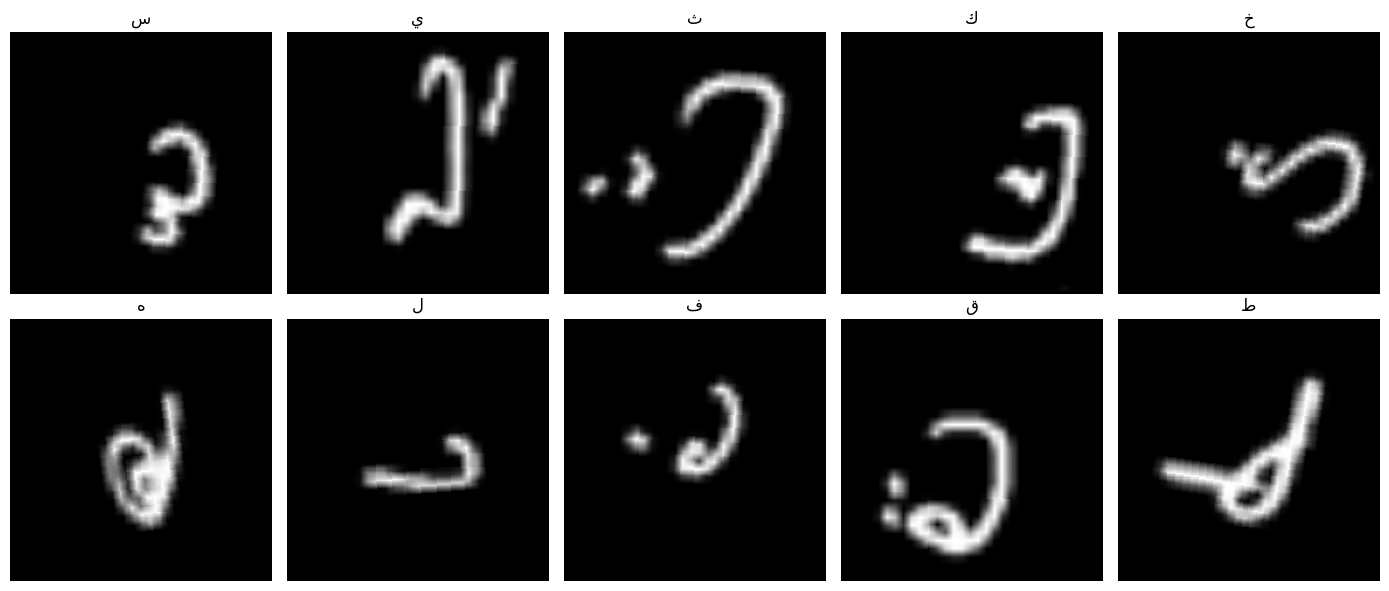

In [10]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(img_tensor.cpu() * std + mean, 0, 1)

def show_batch(dataloader, class_names, rows=2, cols=5):
    images, labels = next(iter(dataloader))
    plt.figure(figsize=(14, 6))
    for i in range(min(rows * cols, len(images))):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(denormalize(images[i]).permute(1, 2, 0))
        plt.title(class_names[labels[i].item()])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(train_loader, class_names)

## 3) Models

We will train:
- A custom CNN from scratch
- A pretrained transfer learning model
- An embedding model for metric learning


In [11]:
class SimpleArabicCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def create_transfer_model(model_name, num_classes, dropout=0.3):
    if model_name == 'resnet18':
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        model = models.resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )
    elif model_name == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )
    elif model_name == 'efficientnet_b1':
        weights = models.EfficientNet_B1_Weights.IMAGENET1K_V1
        model = models.efficientnet_b1(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )
    else:
        raise ValueError(f'Unsupported model_name: {model_name}')
    return model


class EmbeddingNet(nn.Module):
    def __init__(self, backbone_name='efficientnet_b0', embed_dim=128, num_classes=None, dropout=0.2):
        super().__init__()
        self.backbone_name = backbone_name

        if backbone_name == 'resnet18':
            base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            in_features = base.fc.in_features
            base.fc = nn.Identity()
            self.backbone = base

        elif backbone_name == 'efficientnet_b1':
            base = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)
            in_features = base.classifier[1].in_features
            base.classifier = nn.Identity()
            self.backbone = base

        else:
            base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            in_features = base.classifier[1].in_features
            base.classifier = nn.Identity()
            self.backbone = base

        self.embedding_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, embed_dim),
        )
        self.classifier = nn.Linear(embed_dim, num_classes) if num_classes is not None else None

    def forward(self, x, return_embedding=False):
        feats = self.backbone(x)
        emb = self.embedding_head(feats)
        emb = F.normalize(emb, p=2, dim=1)
        if return_embedding or self.classifier is None:
            return emb
        logits = self.classifier(emb)
        return logits, emb

In [12]:
def build_optimizer(model, optimizer_name, lr, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    if optimizer_name == 'adam':
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if optimizer_name == 'adamw':
        return optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    if optimizer_name == 'sgd':
        return optim.SGD(params, lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    raise ValueError(f'Unknown optimizer: {optimizer_name}')

def build_scheduler(optimizer, epochs):
    return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

class EarlyStopping:
    def __init__(self, patience=4, mode='max'):
        self.patience = patience
        self.mode = mode
        self.best = -float('inf') if mode == 'max' else float('inf')
        self.counter = 0
        self.should_stop = False

    def step(self, value):
        improved = value > self.best if self.mode == 'max' else value < self.best
        if improved:
            self.best = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device.type, enabled=scaler is not None):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_preds.extend(outputs.argmax(dim=1).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1

def evaluate_classifier(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)

def fit_classifier(model, train_loader, val_loader, epochs, optimizer_name, lr, freeze_backbone_epochs=0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

    if freeze_backbone_epochs > 0:
        for name, param in model.named_parameters():
            param.requires_grad = ('fc' in name) or ('classifier' in name)

    optimizer = build_optimizer(model, optimizer_name, lr, WEIGHT_DECAY)
    scheduler = build_scheduler(optimizer, epochs)
    early_stopper = EarlyStopping(patience=PATIENCE, mode='max')
    scaler = torch.amp.GradScaler(enabled=USE_MIXED_PRECISION)

    history = defaultdict(list)
    best_state = copy.deepcopy(model.state_dict())
    best_f1 = -1.0

    for epoch in range(1, epochs + 1):
        if freeze_backbone_epochs > 0 and epoch == freeze_backbone_epochs + 1:
            for param in model.parameters():
                param.requires_grad = True
            optimizer = build_optimizer(model, optimizer_name, lr * 0.5, WEIGHT_DECAY)
            scheduler = build_scheduler(optimizer, max(1, epochs - epoch + 1))

        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc, val_f1, _, _ = evaluate_classifier(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f'Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}')

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())

        early_stopper.step(val_f1)
        if early_stopper.should_stop:
            print('Early stopping triggered.')
            break

    model.load_state_dict(best_state)
    return model, history

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'], label='val')
    axes[0].set_title(f'{title} Loss')
    axes[0].legend()

    axes[1].plot(history['train_f1'], label='train_f1')
    axes[1].plot(history['val_f1'], label='val_f1')
    axes[1].set_title(f'{title} Macro F1')
    axes[1].legend()
    plt.show()

## 4) Train CNN From Scratch

/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Epoch 01/20 | train_loss=2.8762 train_acc=0.1396 train_f1=0.1311 | val_loss=3.3203 val_acc=0.0915 val_f1=0.0508


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Epoch 02/20 | train_loss=2.0135 train_acc=0.3385 train_f1=0.3253 | val_loss=3.3501 val_acc=0.0975 val_f1=0.0544


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


...

Epoch 08/20 | train_loss=1.1493 train_acc=0.6553 train_f1=0.6495 | val_loss=6.6004 val_acc=0.1443 val_f1=0.0864


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Epoch 09/20 | train_loss=1.0836 train_acc=0.6813 train_f1=0.6765 | val_loss=10.9477 val_acc=0.1436 val_f1=0.0539


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Epoch 10/20 | train_loss=1.0252 train_acc=0.7019 train_f1=0.6986 | val_loss=9.4026 val_acc=0.1131 val_f1=0.0449
Early stopping triggered.


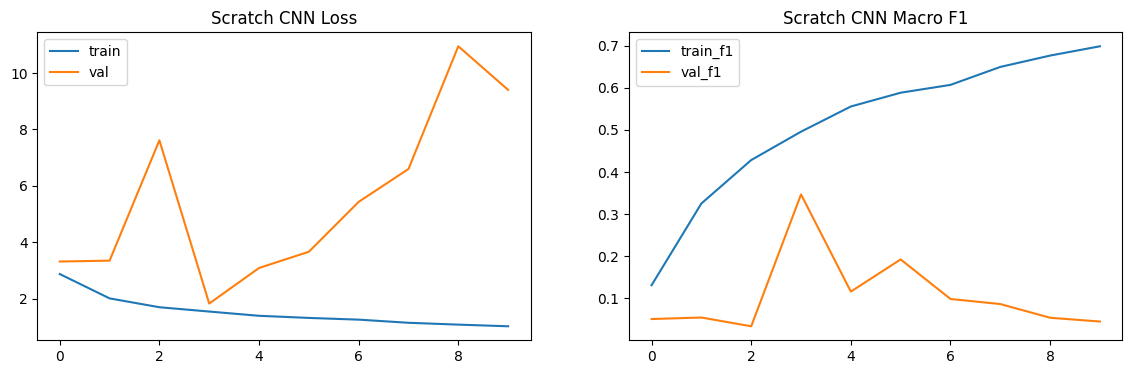

/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Scratch test_acc=0.3937 | test_f1=0.3561


In [13]:
scratch_model = SimpleArabicCNN(num_classes=num_classes, dropout=DROPOUT)
scratch_model, scratch_history = fit_classifier(
    model=scratch_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=NUM_EPOCHS_SCRATCH,
    optimizer_name=SCRATCH_OPTIMIZER,
    lr=LEARNING_RATE_SCRATCH,
)
plot_history(scratch_history, 'Scratch CNN')
scratch_test_loss, scratch_test_acc, scratch_test_f1, y_true_s, y_pred_s = evaluate_classifier(
    scratch_model, test_loader, nn.CrossEntropyLoss()
)
print(f'Scratch test_acc={scratch_test_acc:.4f} | test_f1={scratch_test_f1:.4f}')

## 5) Train Pretrained Transfer Learning Model

Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 253MB/s]
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Epoch 01/20 | train_loss=2.2058 train_acc=0.4478 train_f1=0.4424 | val_loss=0.9728 val_acc=0.8170 val_f1=0.8157


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Epoch 02/20 | train_loss=0.4356 train_acc=0.9134 train_f1=0.9132 | val_loss=0.2276 val_acc=0.9643 val_f1=0.9642


...

Epoch 18/20 | train_loss=0.1015 train_acc=0.9975 train_f1=0.9975 | val_loss=0.1562 val_acc=0.9844 val_f1=0.9844


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Epoch 19/20 | train_loss=0.1017 train_acc=0.9969 train_f1=0.9969 | val_loss=0.1557 val_acc=0.9844 val_f1=0.9844


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Epoch 20/20 | train_loss=0.1028 train_acc=0.9969 train_f1=0.9969 | val_loss=0.1551 val_acc=0.9859 val_f1=0.9859


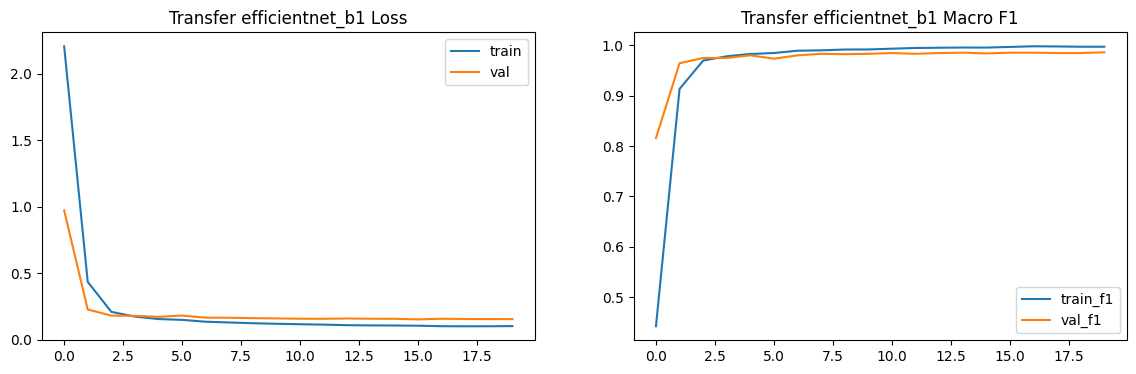

/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Transfer test_acc=0.9872 | test_f1=0.9872


In [14]:
transfer_model = create_transfer_model(TRANSFER_MODEL_NAME, num_classes=num_classes, dropout=DROPOUT)
transfer_model, transfer_history = fit_classifier(
    model=transfer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=NUM_EPOCHS_TRANSFER,
    optimizer_name=TRANSFER_OPTIMIZER,
    lr=LEARNING_RATE_TRANSFER,
    freeze_backbone_epochs=FREEZE_BACKBONE_EPOCHS,
)
plot_history(transfer_history, f'Transfer {TRANSFER_MODEL_NAME}')
transfer_test_loss, transfer_test_acc, transfer_test_f1, y_true_t, y_pred_t = evaluate_classifier(
    transfer_model, test_loader, nn.CrossEntropyLoss()
)
print(f'Transfer test_acc={transfer_test_acc:.4f} | test_f1={transfer_test_f1:.4f}')

In [15]:
labels_all = list(range(num_classes))

print('=== Scratch CNN ===')
print(classification_report(
    y_true_s,
    y_pred_s,
    labels=labels_all,
    target_names=class_names,
    digits=4,
    zero_division=0
))

print('=== Transfer Model ===')
print(classification_report(
    y_true_t,
    y_pred_t,
    labels=labels_all,
    target_names=class_names,
    digits=4,
    zero_division=0
))


=== Scratch CNN ===
              precision    recall  f1-score   support

           أ     0.6667    0.2167    0.3270       120
           ب     0.2778    0.0417    0.0725       120
           ت     0.7561    0.2583    0.3851       120
           ث     0.8588    0.6083    0.7122       120
           ج     0.3924    0.2583    0.3116       120
           ح     0.3149    0.9000    0.4665       120
           خ     0.2071    0.3417    0.2579       120
           د     0.0000    0.0000    0.0000       120
           ذ     1.0000    0.0417    0.0800       120
           ر     0.5385    0.1167    0.1918       120
           ز     0.6344    0.4917    0.5540       120
           س     0.5000    0.2083    0.2941       120
           ش     0.9406    0.7917    0.8597       120
           ص     0.4951    0.8500    0.6258       120
           ض     0.5422    0.7500    0.6294       120
           ط     0.2895    0.0917    0.1392       120
           ظ     0.3913    0.1500    0.2169       120
       

## 6) Image Retrieval Using Learned Embeddings

We will extract embeddings from the best classifier and retrieve the top-k most similar images using cosine similarity.

In [16]:
def get_backbone_embedding_model(trained_model, model_name):
    if model_name == 'resnet18':
        feature_extractor = copy.deepcopy(trained_model)
        feature_extractor.fc = nn.Identity()
        feature_dim = 512
    else:
        feature_extractor = copy.deepcopy(trained_model)
        feature_extractor.classifier = nn.Identity()
        feature_dim = 1280
    feature_extractor = feature_extractor.to(device).eval()
    return feature_extractor, feature_dim

def extract_embeddings(model, dataloader):
    model.eval()
    all_embeddings, all_labels, all_images = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            feats = model(images)
            feats = F.normalize(feats, p=2, dim=1)
            all_embeddings.append(feats.cpu())
            all_labels.append(labels)
            all_images.append(images.cpu())
    return torch.cat(all_embeddings), torch.cat(all_labels), torch.cat(all_images)

best_classifier = transfer_model if transfer_test_f1 >= scratch_test_f1 else scratch_model
best_name = TRANSFER_MODEL_NAME if transfer_test_f1 >= scratch_test_f1 else 'scratch_cnn'
print('Best classifier for retrieval:', best_name)

if best_name == 'scratch_cnn':
    feature_model = nn.Sequential(best_classifier.features, nn.Flatten()).to(device).eval()
else:
    feature_model, feature_dim = get_backbone_embedding_model(best_classifier, TRANSFER_MODEL_NAME)

gallery_embeddings, gallery_labels, gallery_images = extract_embeddings(feature_model, test_loader)
print('Gallery embeddings shape:', gallery_embeddings.shape)

Best classifier for retrieval: efficientnet_b1


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Gallery embeddings shape: torch.Size([3360, 1280])


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


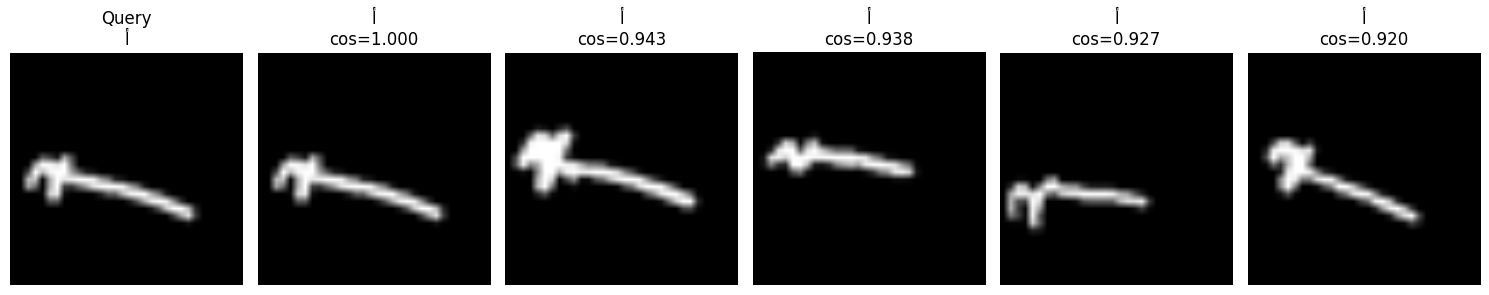

In [17]:
def retrieve_top_k(query_tensor, gallery_embeddings, gallery_images, gallery_labels, feature_model, class_names, k=5):
    if hasattr(feature_model, 'eval'):
        feature_model.eval()
    with torch.no_grad():
        query_embedding = feature_model(query_tensor.unsqueeze(0).to(device))
        query_embedding = F.normalize(query_embedding, p=2, dim=1).cpu()
    sims = F.cosine_similarity(query_embedding, gallery_embeddings)
    topk = torch.topk(sims, k=k)
    return topk.indices, topk.values

def show_retrieval_example(dataset, idx, feature_model, gallery_embeddings, gallery_images, gallery_labels, class_names, k=5):
    query_image, query_label = dataset[idx]
    indices, scores = retrieve_top_k(query_image, gallery_embeddings, gallery_images, gallery_labels, feature_model, class_names, k=k)

    plt.figure(figsize=(2.5 * (k + 1), 3))
    plt.subplot(1, k + 1, 1)
    plt.imshow(denormalize(query_image).permute(1, 2, 0))
    plt.title(f'Query\n{class_names[query_label]}')
    plt.axis('off')

    for j, (retrieved_idx, score) in enumerate(zip(indices.tolist(), scores.tolist()), start=2):
        plt.subplot(1, k + 1, j)
        plt.imshow(denormalize(gallery_images[retrieved_idx]).permute(1, 2, 0))
        plt.title(f'{class_names[gallery_labels[retrieved_idx]]}\ncos={score:.3f}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_retrieval_example(test_dataset, idx=0, feature_model=feature_model, gallery_embeddings=gallery_embeddings, gallery_images=gallery_images, gallery_labels=gallery_labels, class_names=class_names, k=5)

## 7) Phase 3: Metric Learning with Triplet Loss

This stage learns a better embedding space so samples from the same class stay closer together.

In [18]:
class TripletImageFolder(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

        if isinstance(dataset, Subset):
            base_dataset = dataset.dataset
            if hasattr(base_dataset, "targets"):
                base_labels = base_dataset.targets
            elif hasattr(base_dataset, "labels"):
                base_labels = base_dataset.labels
            else:
                raise AttributeError("Base dataset must have 'targets' or 'labels'.")

            self.targets = [int(base_labels[i]) for i in dataset.indices]
        else:
            if hasattr(dataset, "targets"):
                self.targets = [int(x) for x in dataset.targets]
            elif hasattr(dataset, "labels"):
                self.targets = [int(x) for x in dataset.labels]
            else:
                raise AttributeError("Dataset must have 'targets' or 'labels'.")

        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(self.targets):
            self.class_to_indices[label].append(idx)

        self.labels = sorted(self.class_to_indices.keys())

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        anchor_img, anchor_label = self.dataset[idx]
        anchor_label = int(anchor_label)

        positive_idx = idx
        while positive_idx == idx:
            positive_idx = random.choice(self.class_to_indices[anchor_label])

        negative_label = random.choice([lbl for lbl in self.labels if lbl != anchor_label])
        negative_idx = random.choice(self.class_to_indices[negative_label])

        positive_img, _ = self.dataset[positive_idx]
        negative_img, _ = self.dataset[negative_idx]

        return anchor_img, positive_img, negative_img, anchor_label


triplet_train_dataset = TripletImageFolder(train_dataset)
triplet_train_loader = DataLoader(triplet_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

metric_model = EmbeddingNet(backbone_name=TRANSFER_MODEL_NAME, embed_dim=EMBED_DIM, num_classes=num_classes, dropout=0.2).to(device)
metric_optimizer = build_optimizer(metric_model, METRIC_OPTIMIZER, LEARNING_RATE_METRIC, WEIGHT_DECAY)
metric_scheduler = build_scheduler(metric_optimizer, NUM_EPOCHS_METRIC)
triplet_criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)
classification_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
metric_scaler = torch.cuda.amp.GradScaler(enabled=USE_MIXED_PRECISION)

metric_history = defaultdict(list)
best_metric_state = copy.deepcopy(metric_model.state_dict())
best_metric_score = -1.0

for epoch in range(1, NUM_EPOCHS_METRIC + 1):
    metric_model.train()
    running_loss = 0.0

    for anchor, positive, negative, labels in triplet_train_loader:
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)
        labels = labels.to(device)

        metric_optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
            anchor_logits, anchor_emb = metric_model(anchor)
            positive_emb = metric_model(positive, return_embedding=True)
            negative_emb = metric_model(negative, return_embedding=True)

            triplet_loss = triplet_criterion(anchor_emb, positive_emb, negative_emb)
            cls_loss = classification_criterion(anchor_logits, labels)
            loss = triplet_loss + 0.2 * cls_loss

        metric_scaler.scale(loss).backward()
        metric_scaler.step(metric_optimizer)
        metric_scaler.update()
        running_loss += loss.item() * anchor.size(0)

    metric_scheduler.step()
    avg_metric_loss = running_loss / len(triplet_train_loader.dataset)

    metric_model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits, emb = metric_model(images)
            preds = logits.argmax(dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_f1 = f1_score(val_labels, val_preds, average='macro')
    metric_history['train_loss'].append(avg_metric_loss)
    metric_history['val_f1'].append(val_f1)
    print(f'Metric epoch {epoch:02d}/{NUM_EPOCHS_METRIC} | loss={avg_metric_loss:.4f} | val_f1={val_f1:.4f}')

    if val_f1 > best_metric_score:
        best_metric_score = val_f1
        best_metric_state = copy.deepcopy(metric_model.state_dict())

metric_model.load_state_dict(best_metric_state)
print('Best metric-learning val_f1:', best_metric_score)

/tmp/ipykernel_2184/152819711.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  metric_scaler = torch.cuda.amp.GradScaler(enabled=USE_MIXED_PRECISION)
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/152819711.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(sel

Metric epoch 01/20 | loss=0.6900 | val_f1=0.6857


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/152819711.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Metric epoch 02/20 | loss=0.5323 | val_f1=0.9352


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/152819711.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


...

Metric epoch 18/20 | loss=0.0687 | val_f1=0.9836


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/152819711.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_2184/152819711.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], m

Metric epoch 19/20 | loss=0.0678 | val_f1=0.9836


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/152819711.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Metric epoch 20/20 | loss=0.0675 | val_f1=0.9844
Best metric-learning val_f1: 0.985856028516749


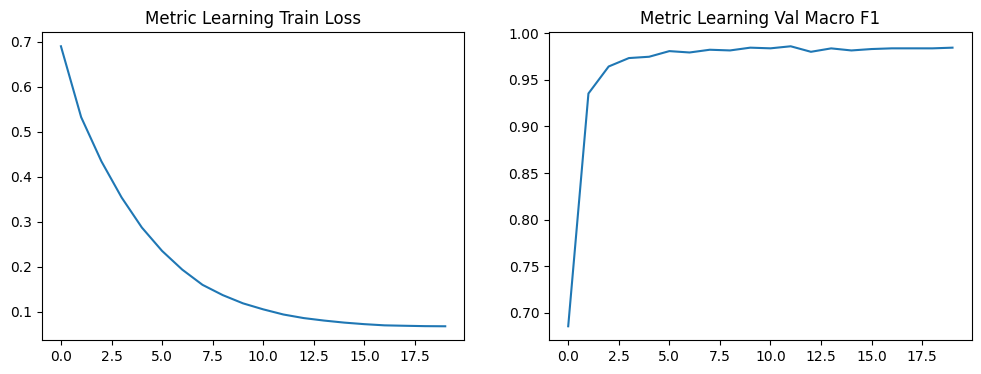

/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")
/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


Metric gallery shape: torch.Size([3360, 128])


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


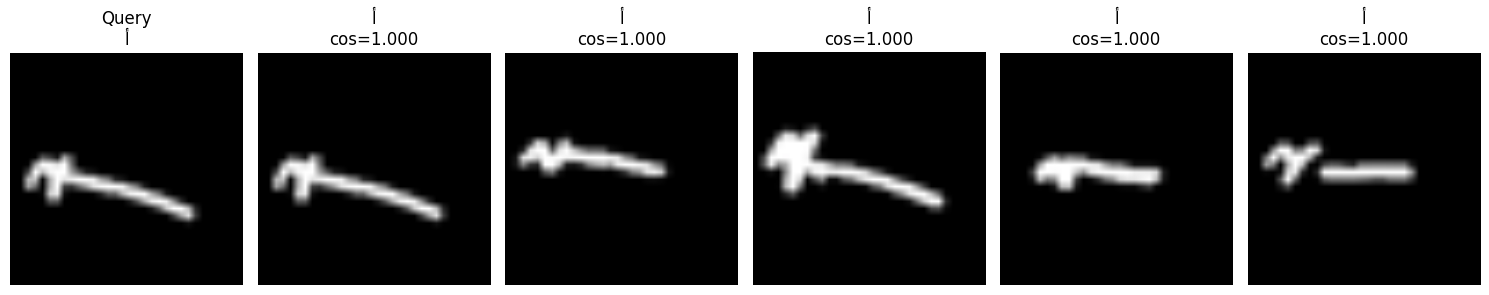

In [19]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(metric_history['train_loss'])
plt.title('Metric Learning Train Loss')

plt.subplot(1, 2, 2)
plt.plot(metric_history['val_f1'])
plt.title('Metric Learning Val Macro F1')
plt.show()

metric_model.eval()
metric_gallery_embeddings = []
metric_gallery_labels = []
metric_gallery_images = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        emb = metric_model(images, return_embedding=True)
        metric_gallery_embeddings.append(emb.cpu())
        metric_gallery_labels.append(labels)
        metric_gallery_images.append(images.cpu())

metric_gallery_embeddings = torch.cat(metric_gallery_embeddings)
metric_gallery_labels = torch.cat(metric_gallery_labels)
metric_gallery_images = torch.cat(metric_gallery_images)
print('Metric gallery shape:', metric_gallery_embeddings.shape)

show_retrieval_example(
    dataset=test_dataset,
    idx=0,
    feature_model=lambda x: metric_model(x, return_embedding=True),
    gallery_embeddings=metric_gallery_embeddings,
    gallery_images=metric_gallery_images,
    gallery_labels=metric_gallery_labels,
    class_names=class_names,
    k=5,
)

In [20]:
def retrieval_at_k(embeddings, labels, ks=(1, 5)):
    embeddings = F.normalize(embeddings, p=2, dim=1)
    sim_matrix = embeddings @ embeddings.T

    results = {k: 0 for k in ks}
    n = len(labels)

    for i in range(n):
        sims = sim_matrix[i].clone()
        sims[i] = -1.0  # exclude self
        ranked_idx = torch.argsort(sims, descending=True)

        ranked_labels = labels[ranked_idx]
        for k in ks:
            topk_labels = ranked_labels[:k]
            if (topk_labels == labels[i]).any():
                results[k] += 1

    for k in ks:
        results[k] /= n

    return results

metric_retrieval_scores = retrieval_at_k(metric_gallery_embeddings, metric_gallery_labels, ks=(1, 5))
print("Metric Retrieval Scores:", metric_retrieval_scores)


Metric Retrieval Scores: {1: 0.981547619047619, 5: 0.9904761904761905}


## 8) Final Notes

Good experiments to try next from the same notebook:
- Change `TRANSFER_MODEL_NAME` between `resnet18` and `efficientnet_b0`
- Compare `adamw` vs `sgd`
- Reduce `IMAGE_SIZE` to 128 for faster runs
- Increase `NUM_EPOCHS_TRANSFER` after the first clean baseline
- Save the best models with `torch.save()` once you are happy with the results

Portfolio angle:
- Show the classification comparison
- Show retrieval examples
- Show that metric learning improved the embedding space


### Retrieval Before vs After Metric Learning

Base Retrieval Scores: {1: 0.9833333333333333, 5: 0.9916666666666667}
Metric Retrieval Scores: {1: 0.981547619047619, 5: 0.9904761904761905}


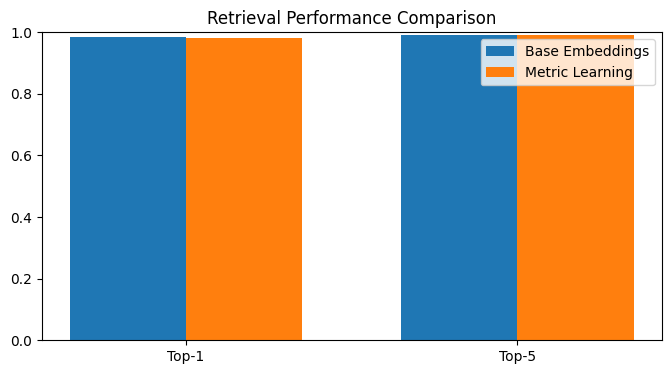

In [21]:
def retrieval_at_k(embeddings, labels, ks=(1, 5)):
    embeddings = F.normalize(embeddings, p=2, dim=1)
    sim_matrix = embeddings @ embeddings.T

    results = {k: 0 for k in ks}
    n = len(labels)

    for i in range(n):
        sims = sim_matrix[i].clone()
        sims[i] = -1.0  # exclude self
        ranked_idx = torch.argsort(sims, descending=True)
        ranked_labels = labels[ranked_idx]

        for k in ks:
            if (ranked_labels[:k] == labels[i]).any():
                results[k] += 1

    for k in ks:
        results[k] /= n

    return results


base_retrieval_scores = retrieval_at_k(gallery_embeddings, gallery_labels, ks=(1, 5))
metric_retrieval_scores = retrieval_at_k(metric_gallery_embeddings, metric_gallery_labels, ks=(1, 5))

print("Base Retrieval Scores:", base_retrieval_scores)
print("Metric Retrieval Scores:", metric_retrieval_scores)

plt.figure(figsize=(8, 4))
x = np.arange(2)
base_vals = [base_retrieval_scores[1], base_retrieval_scores[5]]
metric_vals = [metric_retrieval_scores[1], metric_retrieval_scores[5]]
width = 0.35

plt.bar(x - width/2, base_vals, width, label='Base Embeddings')
plt.bar(x + width/2, metric_vals, width, label='Metric Learning')
plt.xticks(x, ['Top-1', 'Top-5'])
plt.ylim(0, 1)
plt.title('Retrieval Performance Comparison')
plt.legend()
plt.show()


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


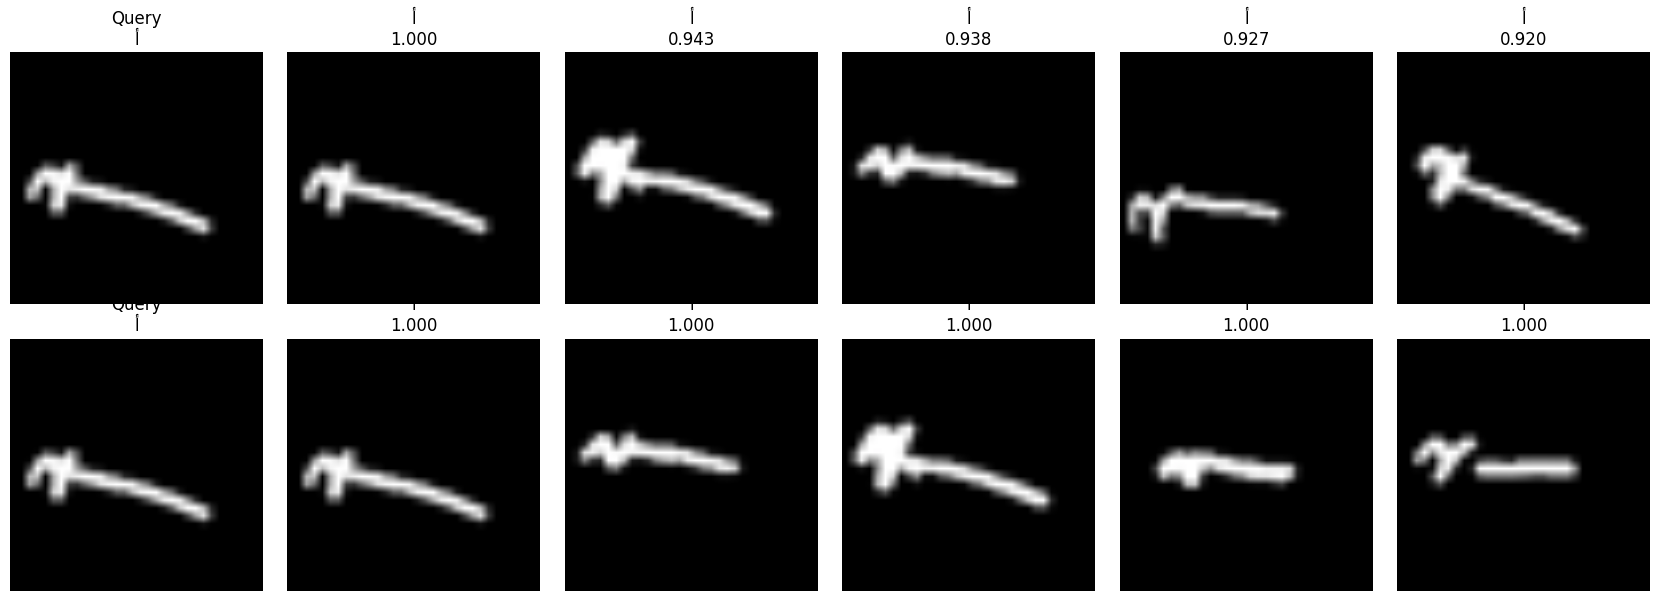

In [22]:
def show_retrieval_comparison(
    dataset,
    idx,
    base_feature_model,
    base_gallery_embeddings,
    base_gallery_images,
    base_gallery_labels,
    metric_feature_model,
    metric_gallery_embeddings,
    metric_gallery_images,
    metric_gallery_labels,
    class_names,
    k=5
):
    query_image, query_label = dataset[idx]

    base_indices, base_scores = retrieve_top_k(
        query_image,
        base_gallery_embeddings,
        base_gallery_images,
        base_gallery_labels,
        base_feature_model,
        class_names,
        k=k
    )

    metric_indices, metric_scores = retrieve_top_k(
        query_image,
        metric_gallery_embeddings,
        metric_gallery_images,
        metric_gallery_labels,
        metric_feature_model,
        class_names,
        k=k
    )

    fig, axes = plt.subplots(2, k + 1, figsize=(2.8 * (k + 1), 6))

    axes[0, 0].imshow(denormalize(query_image).permute(1, 2, 0))
    axes[0, 0].set_title(f"Query\n{class_names[query_label]}")
    axes[0, 0].axis("off")

    axes[1, 0].imshow(denormalize(query_image).permute(1, 2, 0))
    axes[1, 0].set_title(f"Query\n{class_names[query_label]}")
    axes[1, 0].axis("off")

    for j, (rid, score) in enumerate(zip(base_indices.tolist(), base_scores.tolist()), start=1):
        axes[0, j].imshow(denormalize(base_gallery_images[rid]).permute(1, 2, 0))
        axes[0, j].set_title(f"{class_names[base_gallery_labels[rid]]}\n{score:.3f}")
        axes[0, j].axis("off")

    for j, (rid, score) in enumerate(zip(metric_indices.tolist(), metric_scores.tolist()), start=1):
        axes[1, j].imshow(denormalize(metric_gallery_images[rid]).permute(1, 2, 0))
        axes[1, j].set_title(f"{class_names[metric_gallery_labels[rid]]}\n{score:.3f}")
        axes[1, j].axis("off")

    axes[0, 0].set_ylabel("Base", fontsize=12)
    axes[1, 0].set_ylabel("Metric", fontsize=12)

    plt.tight_layout()
    plt.show()


metric_feature_model = lambda x: metric_model(x, return_embedding=True)

show_retrieval_comparison(
    dataset=test_dataset,
    idx=0,
    base_feature_model=feature_model,
    base_gallery_embeddings=gallery_embeddings,
    base_gallery_images=gallery_images,
    base_gallery_labels=gallery_labels,
    metric_feature_model=metric_feature_model,
    metric_gallery_embeddings=metric_gallery_embeddings,
    metric_gallery_images=metric_gallery_images,
    metric_gallery_labels=metric_gallery_labels,
    class_names=class_names,
    k=5
)


##t-SNE Embedding Visualization

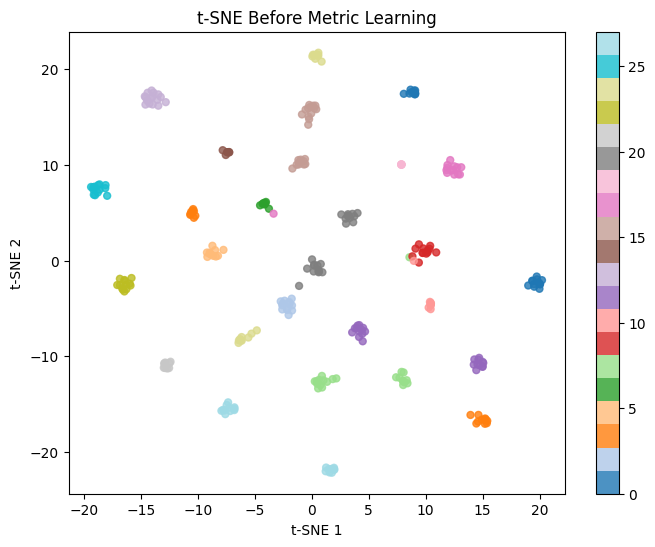

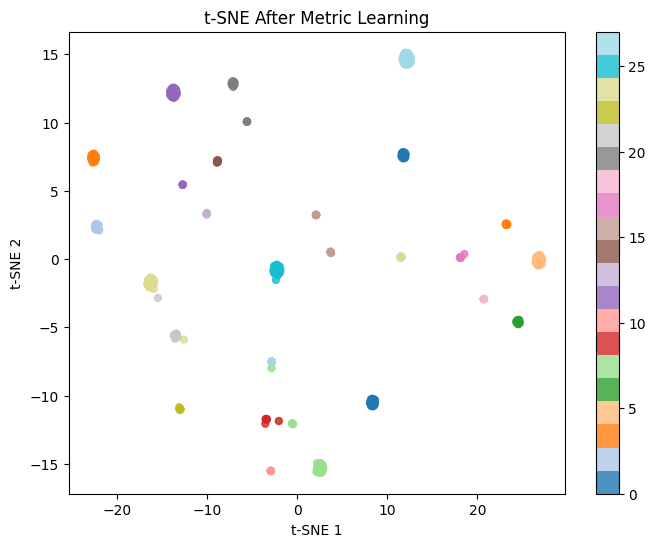

In [23]:
from sklearn.manifold import TSNE

def plot_tsne(embeddings, labels, title, max_points=300):
    embeddings = embeddings.cpu().numpy()
    labels = labels.cpu().numpy()

    if len(embeddings) > max_points:
        idx = np.random.choice(len(embeddings), size=max_points, replace=False)
        embeddings = embeddings[idx]
        labels = labels[idx]

    tsne = TSNE(
        n_components=2,
        random_state=SEED,
        perplexity=min(20, len(embeddings) - 1),
        init='pca'
    )
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        emb_2d[:, 0],
        emb_2d[:, 1],
        c=labels,
        cmap='tab20',
        s=25,
        alpha=0.8
    )
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.colorbar(scatter)
    plt.show()

plot_tsne(gallery_embeddings, gallery_labels, "t-SNE Before Metric Learning")
plot_tsne(metric_gallery_embeddings, metric_gallery_labels, "t-SNE After Metric Learning")


##Grad-CAM

In [24]:
from PIL import Image, ImageFilter
import numpy as np

def preprocess_uploaded_image(input_image, image_size=IMAGE_SIZE, pad=28):
    img = input_image.convert("L")
    arr = np.array(img)

    # invert only if background is bright
    if arr.mean() > 127:
        arr = 255 - arr

    # denoise a bit
    arr = np.array(Image.fromarray(arr).filter(ImageFilter.MedianFilter(size=3)))

    # stronger threshold
    binary = (arr > 100).astype(np.uint8) * 255

    # remove tiny noise by requiring enough foreground pixels per row/col
    ys, xs = np.where(binary > 0)
    if len(xs) == 0 or len(ys) == 0:
        return Image.fromarray(np.zeros((image_size, image_size), dtype=np.uint8))

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    cropped = binary[y1:y2 + 1, x1:x2 + 1]

    h, w = cropped.shape
    side = max(h, w) + pad
    canvas = np.zeros((side, side), dtype=np.uint8)

    y_off = (side - h) // 2
    x_off = (side - w) // 2
    canvas[y_off:y_off + h, x_off:x_off + w] = cropped

    return Image.fromarray(canvas)


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


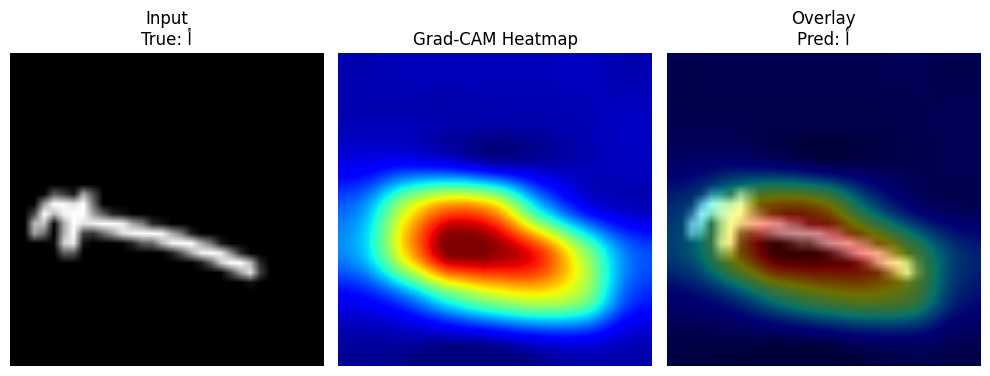

In [25]:
def get_target_layer(model, model_name):
    if model_name == 'resnet18':
        return model.layer4[-1]
    elif model_name in ['efficientnet_b0', 'efficientnet_b1']:
        return model.features[-1]
    else:
        raise ValueError(f"Unsupported model for Grad-CAM: {model_name}")


def make_gradcam_heatmap(model, image_tensor, model_name):
    model.eval()
    activations = []
    gradients = []

    target_layer = get_target_layer(model, model_name)

    def forward_hook(module, inp, out):
        activations.append(out)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    image_tensor = image_tensor.unsqueeze(0).to(device)
    output = model(image_tensor)
    pred_class = output.argmax(dim=1).item()
    score = output[0, pred_class]

    model.zero_grad()
    score.backward()

    acts = activations[0].detach()
    grads = gradients[0].detach()
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1).squeeze()
    cam = F.relu(cam)
    cam = cam / (cam.max() + 1e-8)

    h1.remove()
    h2.remove()

    return cam.cpu().numpy(), pred_class


def show_gradcam(model, dataset, idx, model_name, class_names):
    image, label = dataset[idx]
    heatmap, pred_class = make_gradcam_heatmap(model, image, model_name)

    image_np = denormalize(image).permute(1, 2, 0).numpy()
    heatmap_img = Image.fromarray(np.uint8(heatmap * 255)).resize((image_np.shape[1], image_np.shape[0]))
    heatmap_np = np.array(heatmap_img) / 255.0

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title(f"Input\nTrue: {class_names[label]}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_np, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(image_np)
    plt.imshow(heatmap_np, cmap='jet', alpha=0.45)
    plt.title(f"Overlay\nPred: {class_names[pred_class]}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


show_gradcam(
    model=transfer_model,
    dataset=test_dataset,
    idx=0,
    model_name=TRANSFER_MODEL_NAME,
    class_names=class_names
)


##Gradio Demo

In [26]:
try:
    import gradio as gr
except ImportError:
    !pip -q install gradio
    import gradio as gr




def predict_and_retrieve(input_image):
    image = input_image.convert("L")
    image_tensor = eval_transform(image)

    with torch.no_grad():
        logits = transfer_model(image_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_idx = int(np.argmax(probs))
        pred_label = class_names[pred_idx]
        confidence = float(probs[pred_idx])

    indices, scores = retrieve_top_k(
        image_tensor,
        metric_gallery_embeddings,
        metric_gallery_images,
        metric_gallery_labels,
        lambda x: metric_model(x, return_embedding=True),
        class_names,
        k=5
    )

    gallery = []
    for idx, score in zip(indices.tolist(), scores.tolist()):
        img = denormalize(metric_gallery_images[idx]).permute(1, 2, 0).numpy()
        img = (img * 255).astype(np.uint8)
        caption = f"{class_names[metric_gallery_labels[idx]]} | cos={score:.3f}"
        gallery.append((img, caption))

    preview = image.resize((224, 224))
    summary = f"Predicted character: {pred_label}\nConfidence: {confidence:.3f}"
    return preview, summary, gallery


demo = gr.Interface(
    fn=predict_and_retrieve,
    inputs=gr.Image(type='pil', label='Upload Character Image'),
    outputs=[
        gr.Image(type='pil', label='Input Used by Model'),
        gr.Textbox(label='Prediction Summary'),
        gr.Gallery(label='Top-5 Retrieved Images', columns=5, height=220)
    ],
    title='Arabic Handwritten Character Recognition and Retrieval',
    description='Upload an Arabic handwritten character image to get classification and similarity-based retrieval results.',
)

demo.launch(debug=False)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://046e359e70c2bfa45f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/tmp/ipykernel_2184/3201346453.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(self.images[idx], mode="L")


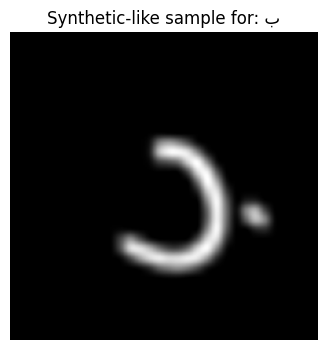

Saved as: synthetic_a_dataset_style.png


In [27]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms.functional as TF

def make_synthetic_from_dataset(target_letter="ب", out_path="synthetic_from_dataset.png"):
    target_idx = class_names.index(target_letter)

    # collect matching samples from test set
    matching = []
    for i in range(len(test_dataset)):
        img_tensor, label = test_dataset[i]
        if int(label) == target_idx:
            matching.append((img_tensor, label))

    if not matching:
        raise ValueError(f"No samples found for letter: {target_letter}")

    img_tensor, label = random.choice(matching)

    # denormalize to PIL grayscale-like image
    img = denormalize(img_tensor).permute(1, 2, 0).numpy()
    img = (img * 255).astype(np.uint8)
    img = Image.fromarray(img).convert("L")

    # light augmentation to create a "new" sample
    angle = random.uniform(-12, 12)
    translate = (random.randint(-8, 8), random.randint(-8, 8))
    scale = random.uniform(0.9, 1.08)
    shear = random.uniform(-6, 6)

    img = TF.affine(
        img,
        angle=angle,
        translate=translate,
        scale=scale,
        shear=shear,
        fill=0
    )

    # optional slight blur / resize to mimic dataset softness
    img = img.resize((32, 32)).resize((224, 224))
    img.save(out_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(np.array(img), cmap="gray")
    plt.title(f"Synthetic-like sample for: {target_letter}")
    plt.axis("off")
    plt.show()

    print("Saved as:", out_path)
    return img

img = make_synthetic_from_dataset(target_letter="ب", out_path="synthetic_a_dataset_style.png")
